In [10]:
from langchain_google_community.calendar.utils import get_google_credentials
creditals=get_google_credentials

In [11]:
!pip install -qU langchain-google-community[gmail]

In [12]:
from langchain_google_community.gmail.utils import build_gmail_service, get_google_credentials

from langchain_google_community import GmailToolkit

In [13]:
from google_auth_oauthlib.flow import InstalledAppFlow
from google.oauth2.credentials import Credentials
from google.auth.transport.requests import Request
import os

SCOPES = ["https://mail.google.com/"]
creds = None
if os.path.exists("gmail_token.json"):
    creds = Credentials.from_authorized_user_file("gmail_token.json", SCOPES)
if not creds or not creds.valid:
    if creds and creds.expired and creds.refresh_token:
        creds.refresh(Request())
    else:
        flow = InstalledAppFlow.from_client_secrets_file("credentials.json", SCOPES)
        flow.redirect_uri = "urn:ietf:wg:oauth:2.0:oob"
        auth_url, _ = flow.authorization_url(prompt="consent")
        print(f"Go to this URL and authorize:\n{auth_url}\n")
        code = input("Paste the authorization code here: ")
        flow.fetch_token(code=code)
        creds = flow.credentials
    with open("gmail_token.json", "w") as token:
        token.write(creds.to_json())

from langchain_google_community import GmailToolkit
from langchain_google_community.gmail.utils import build_gmail_service

gmail_resources = build_gmail_service(credentials=creds)
gmail_toolkit = GmailToolkit(api_resource=gmail_resources)
gmail_tools = gmail_toolkit.get_tools()
gmail_tool_map = {t.name: t for t in gmail_tools}

for t in gmail_tools:
    print(t.name)

Go to this URL and authorize:
https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=913452132560-i6at15pkond7mciojmppasrripk2fhu0.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=https%3A%2F%2Fmail.google.com%2F&state=IAI5Fb0hIsfEttHACacR5h7vYMojW4&code_challenge=iCG2kLgLHjEonFfa8IELPGjm75HXy8o3Eeaherf7ykg&code_challenge_method=S256&prompt=consent&access_type=offline

Paste the authorization code here: 4/1AXEQxIBQtHSpIeNSZCufKhzrLBc3aOsDdIBSg99ZIEPJDkxUlQ2iKwWQanE
create_gmail_draft
send_gmail_message
search_gmail
get_gmail_message
get_gmail_thread


In [14]:
# Check exact tool names and their expected arguments (same habit as before)
for t in gmail_tools:
    print(t.name)
    if t.args_schema:
        for name, field in t.args_schema.model_fields.items():
            print(f"   {name}: {field.annotation}")

create_gmail_draft
   message: <class 'str'>
   to: typing.List[str]
   subject: <class 'str'>
   cc: typing.Optional[typing.List[str]]
   bcc: typing.Optional[typing.List[str]]
send_gmail_message
   message: <class 'str'>
   to: typing.Union[str, typing.List[str]]
   subject: <class 'str'>
   cc: typing.Union[str, typing.List[str], NoneType]
   bcc: typing.Union[str, typing.List[str], NoneType]
search_gmail
   query: <class 'str'>
   resource: <enum 'Resource'>
   max_results: <class 'int'>
get_gmail_message
   message_id: <class 'str'>
get_gmail_thread
   thread_id: <class 'str'>


In [19]:
gmail_tool_map["send_gmail_message"].invoke({
    "message": "Hi Ruchi\n just want to love my devi i love her i god!\n\nBest,\nYour Name",
    "to": ["ruchishende153@gmail.com"],
    "subject": "Happy Birthday!"
})

'Message sent. Message Id: 19f8b4d4e92a1f1e'

In [21]:
! pip install -q langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.1 MB/s eta 0:00:00


In [25]:
from langchain_groq import ChatGroq
from google.colab import userdata  # set via 🔑 icon in Colab sidebar

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=userdata.get('GROQ_API_KEY')
)
llm_with_gmail_tools = llm.bind_tools(gmail_tools)

# ---------------- HELPER: system prompt for email tasks ----------------
from datetime import datetime
import pytz

def get_gmail_system_prompt():
    tz = pytz.timezone("Asia/Kolkata")
    today_str = datetime.now(tz).strftime("%Y-%m-%d")
    return f"""You are an email assistant that drafts or sends Gmail messages from natural language.

Today's date is {today_str}.

Rules:
- Figure out the recipient's email address only if the user gives one explicitly. If the user only gives a name (e.g. "shruti") with no email address, do NOT invent one — ask for it instead by not calling any tool, and instead just respond normally asking for the email address.
- Write a clear, polite "subject" line based on what the user asked for.
- Write a complete, natural-sounding "message" body — don't just repeat the user's words, actually compose a proper short email.
- Default to creating a DRAFT (create_gmail_draft) unless the user explicitly says "send" — sending is irreversible, drafting is safe.
- If the user's message is ambiguous about who the email is to, do not guess — ask for clarification instead of calling a tool.
"""

# ---------------- MAIN: type natural language, it drafts/sends the email ----------------
def handle_email_request(user_text):
    response = llm_with_gmail_tools.invoke([
        ("system", get_gmail_system_prompt()),
        ("human", user_text)
    ])

    if not response.tool_calls:
        # No tool call means the LLM likely needs clarification (e.g. missing email address)
        print(response.content)
        return

    for tool_call in response.tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        print("Extracted:", tool_args)   # always check before trusting it

        if tool_name in gmail_tool_map:
            try:
                result = gmail_tool_map[tool_name].invoke(tool_args)
                print(result)
            except Exception as e:
                print(f"Tool call failed: {e}")
        else:
            print(f"Tool '{tool_name}' not found in gmail_tool_map")

# ---------------- Try it ----------------
user_input = input("What email would you like to send? ")
handle_email_request(user_input)

What email would you like to send? search_gmail about happpy birthday plz
Extracted: {'max_results': 10, 'query': 'subject:happy birthday', 'resource': 'messages'}
[{'id': '19f8b4d4e92a1f1e', 'threadId': '19f8b4d4e92a1f1e', 'snippet': 'Hi Ruchi just want to love my devi i love her i god! Best, Your Name', 'body': '', 'subject': 'Happy Birthday!', 'sender': 'ruchi shende <ruchishende153@gmail.com>'}, {'id': '19f8b4b47ff9276e', 'threadId': '19f8b4b47ff9276e', 'snippet': 'Hi Shruti, \\i just what to love my devi i love her i god ! Best, Your Name', 'body': '', 'subject': 'Happy Birthday!', 'sender': 'ruchi shende <ruchishende153@gmail.com>'}, {'id': '19f8b4ac93ed0918', 'threadId': '19f8b4ac93ed0918', 'snippet': 'Hi Shruti, Just wanted to wish you a happy birthday! Best, Your Name', 'body': '', 'subject': 'Happy Birthday!', 'sender': 'ruchi shende <ruchishende153@gmail.com>'}, {'id': '19f8a9aada268310', 'threadId': '19f8a9aada268310', 'snippet': 'Hi Shruti, Just wanted to wish you a happy 

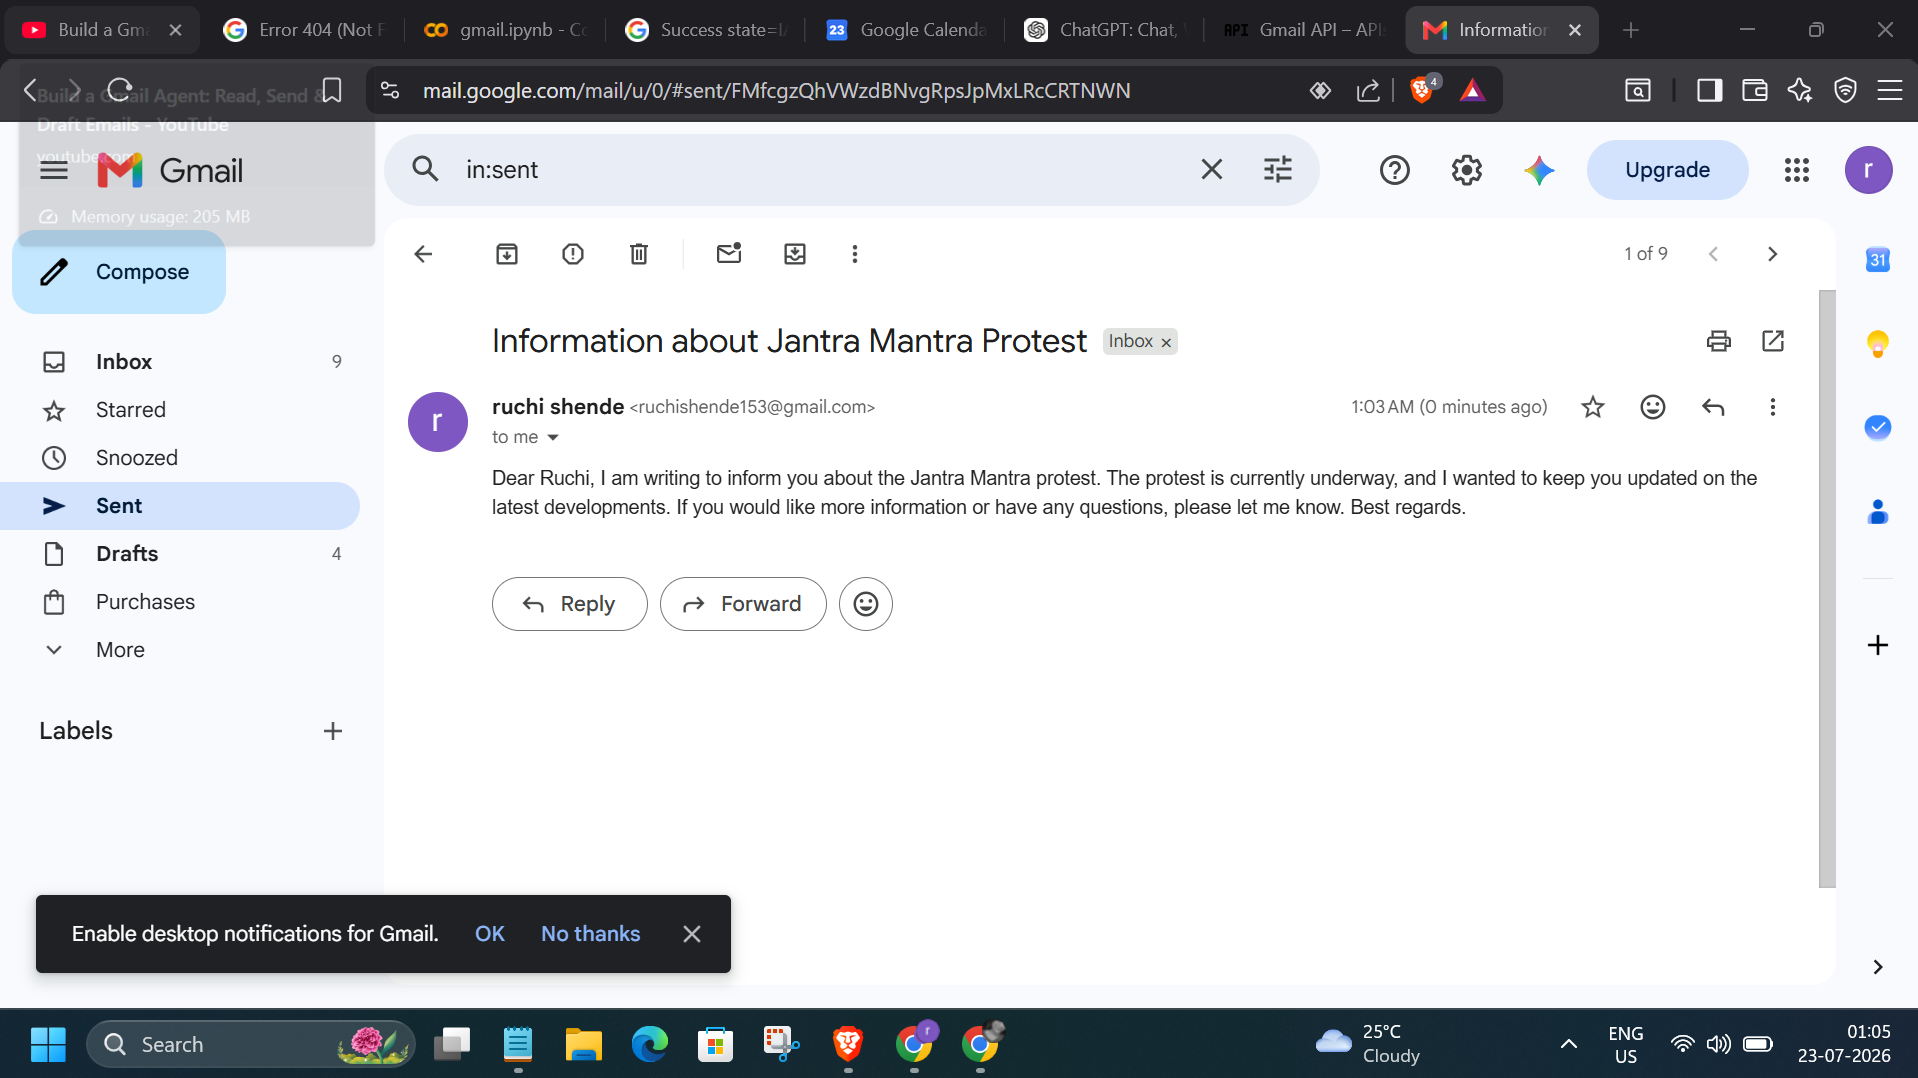

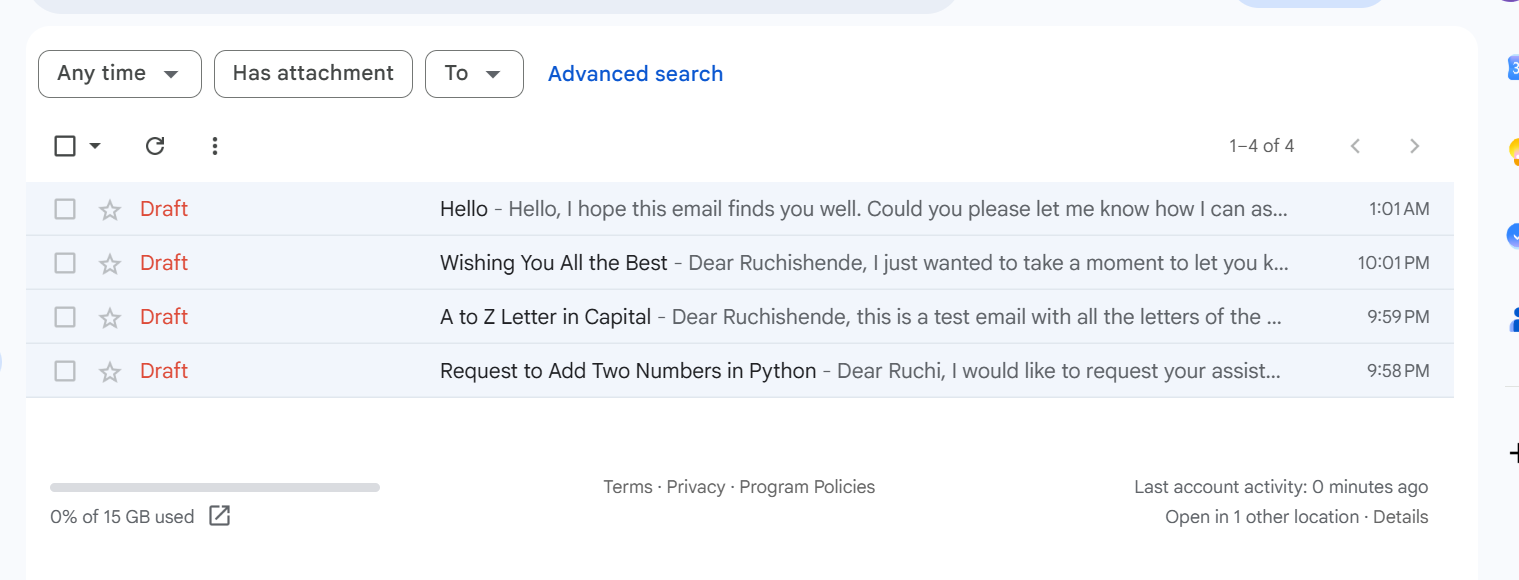